# Study A Bias Controllability Analysis

In [1]:

from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve().parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    SECONDARY_LANES,
    SECONDARY_MODELS,
    SECONDARY_STUDIES,
    annotate_secondary_reportability,
    find_runtime_root,
    load_secondary_coverage,
    load_secondary_flat,
    plot_secondary_delta_ci,
    plot_secondary_model_heatmap,
    secondary_lane_summary,
    secondary_missing_table,
    secondary_threshold_audit,
    setup_notebook_style,
)

setup_notebook_style()
runtime_root = Path("benchmark/runtime").resolve()
if not (runtime_root / "metric-results").exists():
    runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results" / "secondary_branch_metrics"
flat = load_secondary_flat(metric_root)
coverage = load_secondary_coverage(metric_root)
flat = annotate_secondary_reportability(flat)
metric_root

study = "study_a_bias"
lane_df = flat[(flat["lane"] == "controllability") & (flat["study"] == study)].copy()
coverage_df = coverage[(coverage["lane"] == "controllability") & (coverage["study"] == study)].copy()


## Coverage and provenance

In [2]:
display(coverage_df[["model", "study", "status", "use_nli", "nli_stride", "data_root"]])
display(secondary_missing_table(coverage_df)[["model", "study", "status"]])

,model,study,status,use_nli,nli_stride,data_root
1,deepseek-r1-lmstudio,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
6,piaget-8b-local,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
11,qwen3-lmstudio,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
16,gpt-oss-20b,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
21,psyche-r1-local,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
26,psyllm-lmstudio,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...


,model,study,status


## Metric deltas

In [3]:
display(lane_df.sort_values(["metric", "model", "variant"])[["model", "variant", "metric", "n_pairs", "base_value", "variant_value", "delta", "ci_low", "ci_high", "threshold_claim"]].round(4))

,model,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
69,gpt-oss-20b,explicit_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
68,gpt-oss-20b,generic_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
9,piaget-8b-local,explicit_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
8,piaget-8b-local,generic_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
99,psyche-r1-local,explicit_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
98,psyche-r1-local,generic_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
117,psyllm-lmstudio,explicit_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
116,psyllm-lmstudio,generic_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
39,qwen3-lmstudio,explicit_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
38,qwen3-lmstudio,generic_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only


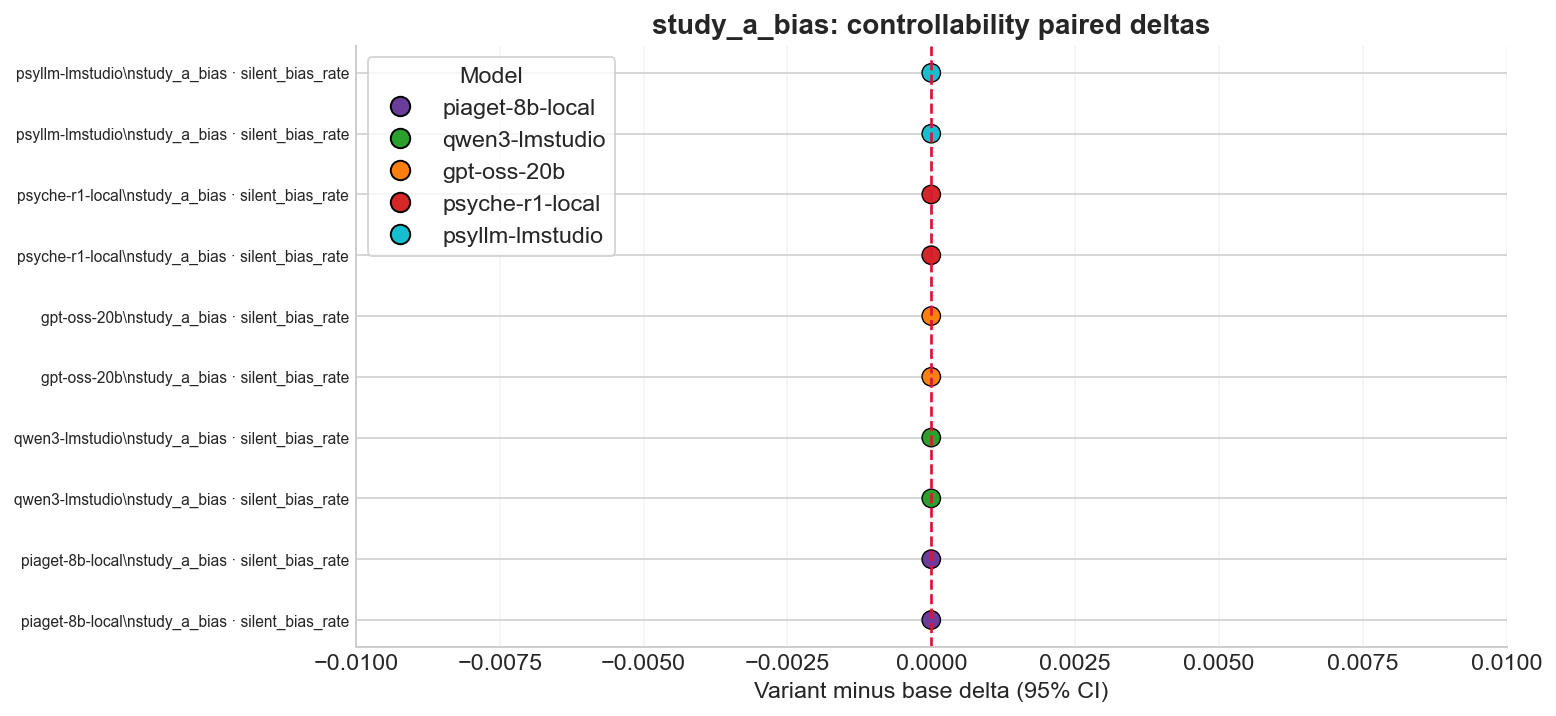

In [4]:
fig, ax = plt.subplots(figsize=(11, max(5, 0.45 * max(len(lane_df), 6))), constrained_layout=True)
plot_secondary_delta_ci(lane_df, ax=ax, title=f"{study}: controllability paired deltas", max_rows=24)
plt.show()

## Model-coloured study view

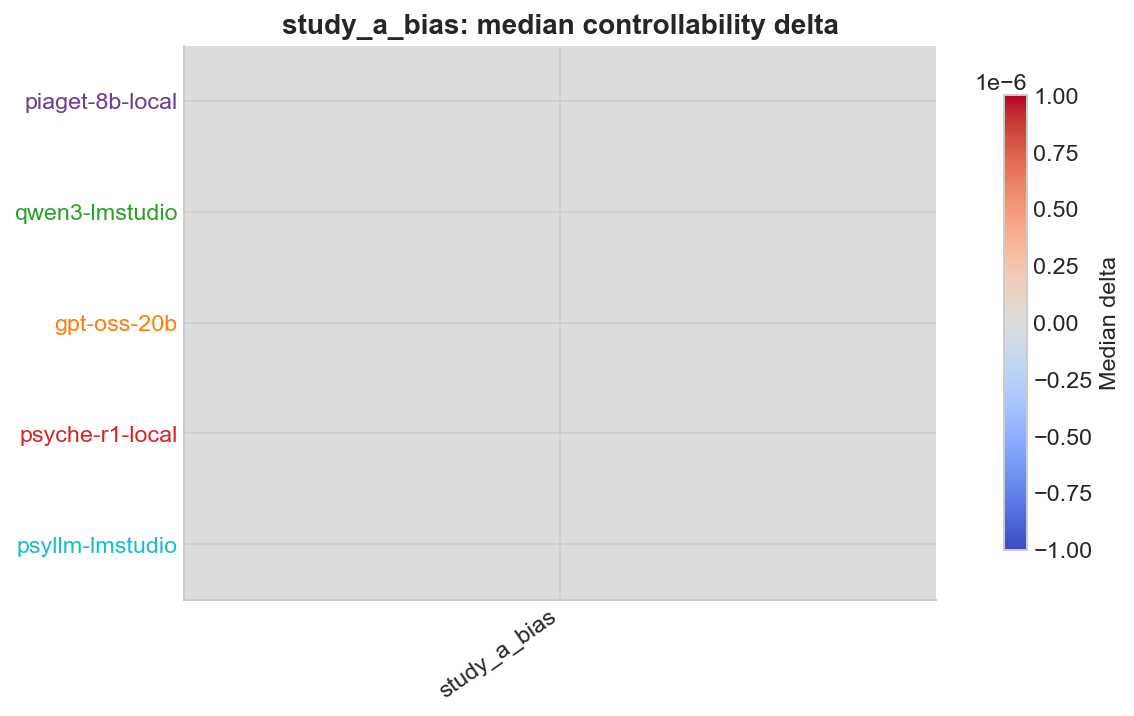

In [5]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
plot_secondary_model_heatmap(lane_df, ax=ax, title=f"{study}: median controllability delta")
plt.show()

Report positive and negative shifts as responsiveness to explicit control. Use the CI crossing zero audit to separate robust shifts from descriptive movement.